Inizio estrazione totale da 191 video...
Estrazione completata! Totale immagini: 9816
Inizio estrazione totale da 63 video...
Estrazione completata! Totale immagini: 3247

Inizio addestramento...
Epoch 1/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 126s 248ms/step - accuracy: 0.9086 - loss: 0.3448 - val_accuracy: 0.9491 - val_loss: 0.1298
Epoch 2/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 115s 234ms/step - accuracy: 0.9772 - loss: 0.1131 - val_accuracy: 0.9145 - val_loss: 0.1848
Epoch 3/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 118s 240ms/step - accuracy: 0.9916 - loss: 0.0596 - val_accuracy: 0.9414 - val_loss: 0.1303
Epoch 4/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 111s 226ms/step - accuracy: 0.9940 - loss: 0.0391 - val_accuracy: 0.9552 - val_loss: 0.0915
Epoch 5/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 115s 235ms/step - accuracy: 0.9969 - loss: 0.0238 - val_accuracy: 0.9252 - val_loss: 0.1739
Epoch 6/25
491/491 ━━━━━━━━━━━━━━━━━━━━ 116s 236ms/step - accuracy: 0.9980 - loss: 0.0179 - val_accuracy: 0.9598 - val_loss: 0.0823
Epoch 7/25
4

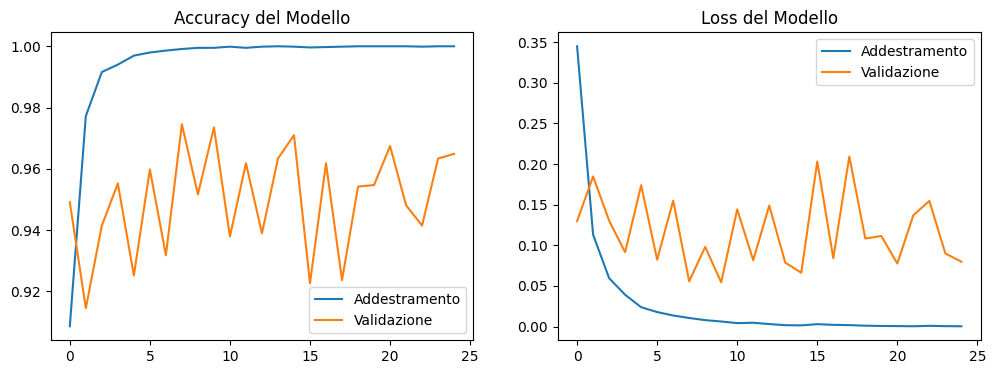

102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 369ms/step

--- REPORT DI CLASSIFICAZIONE (F1-Score) ---
              precision    recall  f1-score   support

       Heavy       0.99      0.97      0.98       571
      Medium       0.92      0.98      0.95       569
       Light       1.00      0.99      0.99      2107

    accuracy                           0.98      3247
   macro avg       0.97      0.98      0.97      3247
weighted avg       0.98      0.98      0.98      3247



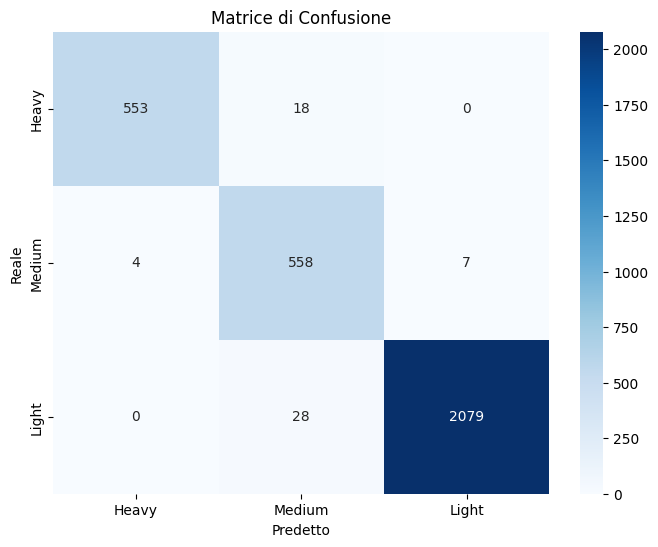

In [ ]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# 1. Path configuration 
# ==========================================
PATH_MASTER = 'data/htvd/ImageMaster'
PATH_TRAIN_SET = 'data/htvd/EvalSet_train'
PATH_TEST_SET = 'data/htvd/EvalSet_test'
PATH_VIDEOS = 'data/htvd/video/' 

# ==========================================
# 2. File reading and preprocessing 
# ==========================================

# ImageMaster contains the labels and filenames
master_df = pd.read_csv(PATH_MASTER, sep='\s+', header=None, comment='#', 
                        names=['index', 'filename', 'label'])

# Mapping labels to numerical values
class_map = {'heavy': 0, 'medium': 1, 'light': 2}
master_df['label_num'] = master_df['label'].map(class_map)

# Function to read EvalSet with varying line lengths
def load_eval_set(filepath):
    with open(filepath, 'r') as f:
        return [list(map(int, line.strip().split(','))) for line in f if line.strip()]

# Load the first row (Fold 1) for Train and Test
train_indices = load_eval_set(PATH_TRAIN_SET)[0]
test_indices = load_eval_set(PATH_TEST_SET)[0]

# ==========================================
# 3. FRAME EXTRACTION AND PREPROCESSING 
# ==========================================

def process_video_indices(indices_list):
    X, y = [], []
    print(f"Inizio estrazione totale da {len(indices_list)} video...")
    
    for idx in indices_list:
        row = master_df.iloc[idx]
        v_path = os.path.join(PATH_VIDEOS, f"{row['filename']}.avi")
        
        cap = cv.VideoCapture(v_path)
        
        # Starting from frame index 1 (the second frame)
        cap.set(cv.CAP_PROP_POS_FRAMES, 1)
        
        count_video_frames = 0
        while True:
            success, frame = cap.read()
            if not success:
                break
            
            # --- PREPROCESSING
            # 1. cutting to remove text
            cropped = frame[50:220, :]
            
            # 2. Resize for the neural network (224x224)
            resized = cv.resize(cropped, (224, 224))
            
            # 3. Normalization and adding to the list
            X.append(resized.astype('float32') / 255.0)
            y.append(row['label_num'])
            
            count_video_frames += 1
            
        cap.release()
        # Optional debug to see progress
        # print(f"Video {row['filename']}: extracted {count_video_frames} frames.")
    
    X = np.array(X)
    y = np.array(y)
    print(f"Extraction completed! Total images: {len(X)}")
    return X, y

# Execution
X_train, y_train = process_video_indices(train_indices)
X_test, y_test = process_video_indices(test_indices)

# Class Imbalance Handling
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# ==========================================
# 4. Model Development
# ==========================================

# Existing base: MobileNetV2 pre-trained on ImageNet
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False # Freeze weights (Baseline)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # regularization
    layers.Dense(3, activation='softmax') # 3 classes: Heavy, Medium, Light
])

model.compile(optimizer=optimizers.Adam(learning_rate=5e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. TRAINING and CURVES 
# ==========================================

print("\nTraining started...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # Creates automatic validation set
    epochs=25,
    batch_size=16,
    class_weight=class_weights_dict,
    verbose=1
)

# Visualizzazione Curve (Linea 60)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.legend()
plt.show()

# ==========================================
# 6. FINAL EVALUATION
# ==========================================

# Predictions on Test Set
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- CLASSIFICATION REPORT (F1-Score) ---")
print(classification_report(y_test, y_pred, target_names=['Heavy', 'Medium', 'Light']))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Heavy', 'Medium', 'Light'],
            yticklabels=['Heavy', 'Medium', 'Light'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

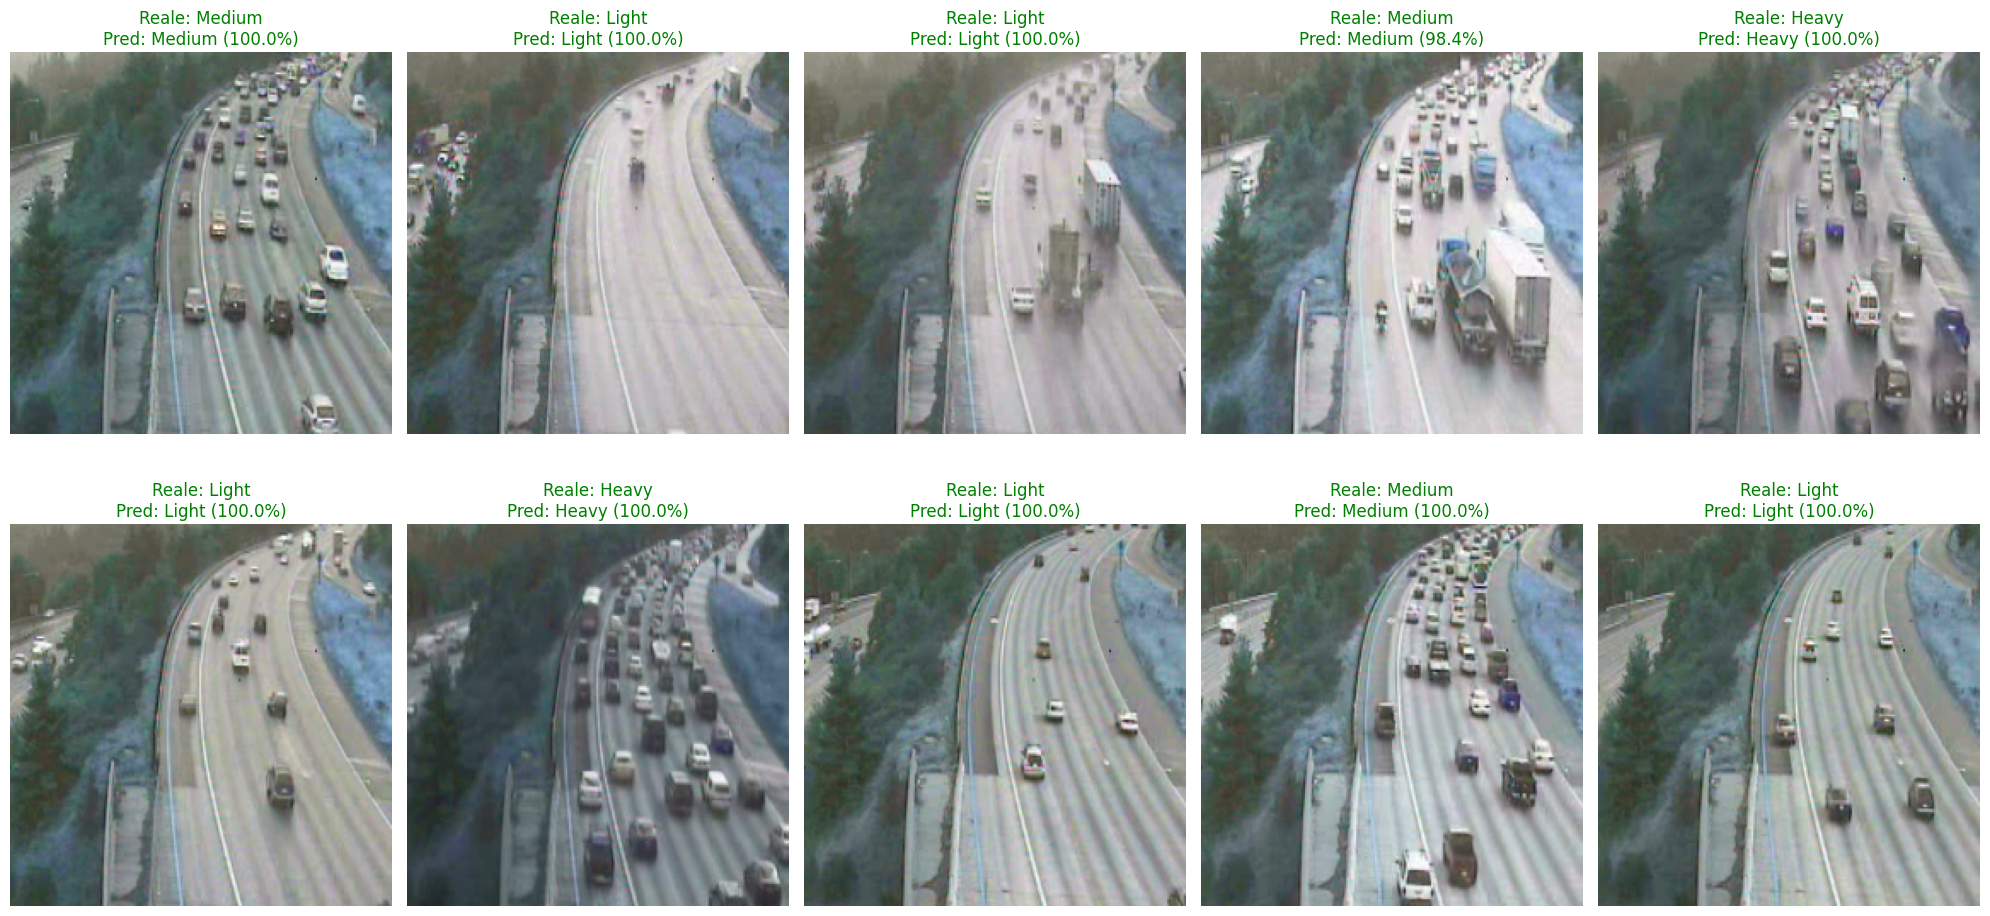

In [11]:
# ==========================================
# 7. VERIFICA VISIVA (10 Esempi dal Test Set)
# ==========================================

def visualize_predictions(X_test, y_test, model, num_samples=10):
    # Mapping inverso per mostrare i nomi delle classi
    inv_class_map = {0: 'Heavy', 1: 'Medium', 2: 'Light'}
    
    # Selezione casuale di indici dal test set
    indices = np.random.choice(len(X_test), num_samples, replace=False)
    
    plt.figure(figsize=(20, 10))
    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = inv_class_map[y_test[idx]]
        
        # Predizione del modello
        pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_idx = np.argmax(pred_probs)
        pred_label = inv_class_map[pred_idx]
        confidence = np.max(pred_probs) * 100
        
        # Plotting
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        
        # Colore del titolo: Verde se corretta, Rosso se sbagliata
        color = 'green' if true_label == pred_label else 'red'
        
        plt.title(f"Reale: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
                  color=color, fontsize=12)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Esegui la visualizzazione
visualize_predictions(X_test, y_test, model)

In [ ]:
import os
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# 1. Path configuration 
# ==========================================
PATH_MASTER = 'data/htvd/ImageMaster'
PATH_TRAIN_SET = 'data/htvd/EvalSet_train'
PATH_TEST_SET = 'data/htvd/EvalSet_test'
PATH_VIDEOS = 'data/htvd/video/' 

# ==========================================
# 2. File reading and preprocessing 
# ==========================================

# ImageMaster contains the labels and filenames
master_df = pd.read_csv(PATH_MASTER, sep='\s+', header=None, comment='#', 
                        names=['index', 'filename', 'label'])

# Mapping labels to numerical values
class_map = {'heavy': 0, 'medium': 1, 'light': 2}
master_df['label_num'] = master_df['label'].map(class_map)

# Function to read EvalSet with varying line lengths
def load_eval_set(filepath):
    with open(filepath, 'r') as f:
        return [list(map(int, line.strip().split(','))) for line in f if line.strip()]

# Load the first row (Fold 1) for Train and Test
train_indices = load_eval_set(PATH_TRAIN_SET)[0]
test_indices = load_eval_set(PATH_TEST_SET)[0]

# ==========================================
# 3. FRAME EXTRACTION AND PREPROCESSING 
# ==========================================

def process_video_indices(indices_list):
    X, y = [], []
    print(f"Inizio estrazione totale da {len(indices_list)} video...")
    
    for idx in indices_list:
        row = master_df.iloc[idx]
        v_path = os.path.join(PATH_VIDEOS, f"{row['filename']}.avi")
        
        cap = cv.VideoCapture(v_path)
        
        # Starting from frame index 1 (the second frame)
        cap.set(cv.CAP_PROP_POS_FRAMES, 1)
        
        count_video_frames = 0
        while True:
            success, frame = cap.read()
            if not success:
                break
            
            # --- PREPROCESSING
            # 1. cutting to remove text
            cropped = frame[50:220, :]
            
            # 2. Resize for the neural network (224x224)
            resized = cv.resize(cropped, (224, 224))
            
            # 3. Normalization and adding to the list
            X.append(resized.astype('float32') / 255.0)
            y.append(row['label_num'])
            
            count_video_frames += 1
            
        cap.release()
        # Optional debug to see progress
        # print(f"Video {row['filename']}: extracted {count_video_frames} frames.")
    
    X = np.array(X)
    y = np.array(y)
    print(f"Extraction completed! Total images: {len(X)}")
    return X, y

# Execution
X_train, y_train = process_video_indices(train_indices)
X_test, y_test = process_video_indices(test_indices)

# Class Imbalance Handling
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# ==========================================
# 4. Model Development
# ==========================================

# Existing base: MobileNetV2 pre-trained on ImageNet
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False # Freeze weights (Baseline)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Regolarizzazione (Linea 57)
    layers.Dense(3, activation='softmax') # 3 classi: H, M, L
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 5. TRAINING and CURVES 
# ==========================================

print("\nTraining started...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2, # Creates automatic validation set
    epochs=25,
    batch_size=16,
    class_weight=class_weights_dict,
    verbose=1
)

# Visualizzazione Curve (Linea 60)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.legend()
plt.show()

# ==========================================
# 6. FINAL EVALUATION
# ==========================================

# Predictions on Test Set
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n--- CLASSIFICATION REPORT (F1-Score) ---")
print(classification_report(y_test, y_pred, target_names=['Heavy', 'Medium', 'Light']))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Heavy', 'Medium', 'Light'],
            yticklabels=['Heavy', 'Medium', 'Light'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

   index                  filename  label
0      0  cctv052x2004080516x01646  heavy
1      1  cctv052x2004080516x01649  heavy
2      2  cctv052x2004080517x01652  heavy
3      3  cctv052x2004080517x01653  heavy
4      4  cctv052x2004080517x01654  heavy
